In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

In [29]:
df = pd.read_csv('..\\SampleData\\SampleData\\Titanic (1).csv')

In [30]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [31]:
dat = df[['Pclass','Sex', 'Age','Survived' ]]
dat = dat.dropna()

In [32]:
d = {'female': 0, 'male': 1}
dat['Sex'] = dat['Sex'].map(d)

In [33]:
x =  dat[['Pclass','Sex', 'Age']]
y = dat['Survived']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.1)

In [35]:
from sklearn.linear_model import  LogisticRegression
# model = LogisticRegression().fit(X_train[['Sex']], y_train)
model = LogisticRegression().fit(X_train, y_train)


In [36]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
intercept = model.intercept_
coef = model.coef_
score = model.score(X_train, y_train) 
prob_matrix = model.predict_proba(X_train)

In [38]:
print('Intercept:', intercept)
print('Coefficient:', coef)
print('Score:', score)
print('Probability Matrix:\n', prob_matrix)

Intercept: [4.88888533]
Coefficient: [[-1.25976451 -2.3538918  -0.03806358]]
Score: 0.794392523364486
Probability Matrix:
 [[0.10845917 0.89154083]
 [0.93870366 0.06129634]
 [0.04486618 0.95513382]
 ...
 [0.85999564 0.14000436]
 [0.29292704 0.70707296]
 [0.10131441 0.89868559]]


In [39]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_train)
print('Classification Report:\n', classification_report(y_train, y_pred))
cm = confusion_matrix(y_train, y_pred)
print('Confusion Matrix:\n', cm)

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       383
           1       0.76      0.71      0.74       259

    accuracy                           0.79       642
   macro avg       0.79      0.78      0.78       642
weighted avg       0.79      0.79      0.79       642

Confusion Matrix:
 [[326  57]
 [ 75 184]]


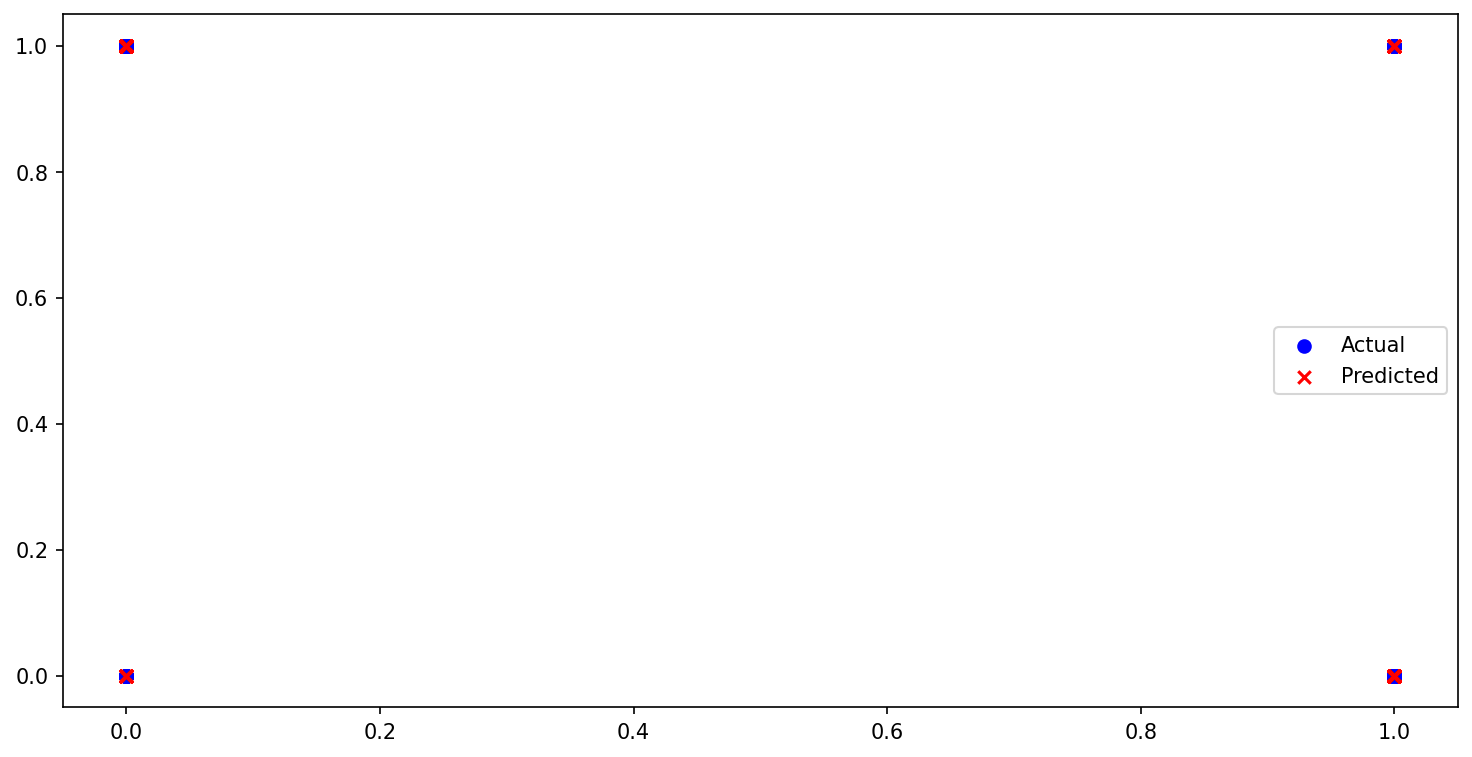

In [40]:
plt.scatter(X_train[['Sex']], y_train, color='blue', label='Actual', marker='o')
plt.scatter(X_train[['Sex']], y_pred, color='red', label='Predicted', marker='x')
plt.legend()
plt.show()

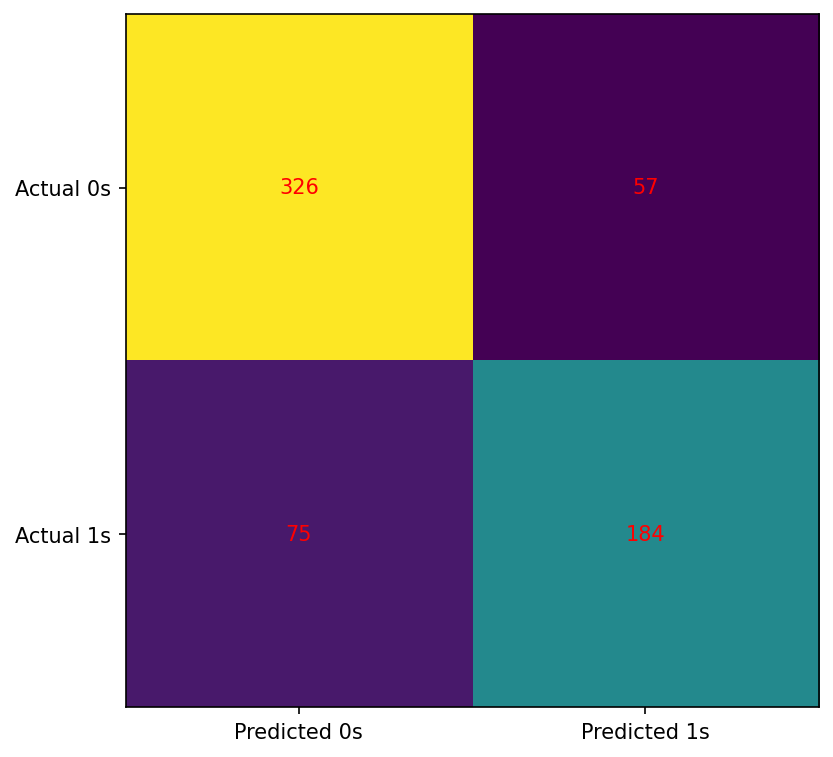

In [41]:
fig, ax = plt.subplots()
ax.imshow(cm)
ax.xaxis.set(ticks = (0,1), ticklabels = ('Predicted 0s', 'Predicted 1s'))
ax.yaxis.set(ticks = (0,1), ticklabels = ('Actual 0s', 'Actual 1s'))
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='red')
plt.show()

In [42]:
pred_values = model.predict(X_test)
pred_score = model.score(X_test, y_test)
pred_prob_matrix = model.predict_proba(X_test)


In [43]:
print(pred_values)
print(pred_score)
print(pred_prob_matrix)

[1 0 0 1 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1
 1 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0]
0.7777777777777778
[[0.26241296 0.73758704]
 [0.52466153 0.47533847]
 [0.71831628 0.28168372]
 [0.2774116  0.7225884 ]
 [0.90970846 0.09029154]
 [0.87734321 0.12265679]
 [0.74738487 0.25261513]
 [0.95405553 0.04594447]
 [0.91576949 0.08423051]
 [0.39545304 0.60454696]
 [0.50807823 0.49192177]
 [0.90325735 0.09674265]
 [0.44782842 0.55217158]
 [0.86451613 0.13548387]
 [0.15110743 0.84889257]
 [0.13301847 0.86698153]
 [0.24024777 0.75975223]
 [0.91278658 0.08721342]
 [0.8689129  0.1310871 ]
 [0.70189367 0.29810633]
 [0.15157831 0.84842169]
 [0.89987979 0.10012021]
 [0.80046799 0.19953201]
 [0.898152   0.101848  ]
 [0.89639783 0.10360217]
 [0.59858403 0.40141597]
 [0.55542965 0.44457035]
 [0.43236881 0.56763119]
 [0.91576949 0.08423051]
 [0.70266022 0.29733978]
 [0.20724057 0.79275943]
 [0.82965809 0.17034191]
 [0.37740568 0.62259432]
 [0.92933